# L4. Contextual Filtering for Memory

Similarity alone can't tell this morning's coffee from yesterday's. This lesson adds metadata filters — a time window, and a semantic query plus a payload filter — inside the same on-device query.

## 1. Memories with metadata

In [1]:
from datetime import datetime, timezone

BASE = 1_699_920_000  # fixed "today 00:00:00 UTC" (2023-11-14)


def at(hours):  # readable epoch for a time of day
    return BASE + int(hours * 3600)


memories = [
    {"note": "Cappuccino at the 5th St cafe, sat outside",
     "category": "food", "timestamp": at(8), "price": 4.5},
    {"note": "Team standup about the Q3 roadmap",
     "category": "work", "timestamp": at(10), "price": 0.0},
    {"note": "New notebook and pens from the stationers",
     "category": "shopping", "timestamp": at(11), "price": 12.0},
    {"note": "Ramen place downtown for lunch",
     "category": "food", "timestamp": at(13), "price": 14.0},
    {"note": "Tasting menu at the fancy bistro tonight",
     "category": "food", "timestamp": at(20), "price": 85.0},
    {"note": "Black and white running shoes at the mall",
     "category": "shopping", "timestamp": at(15), "price": 45.0},
    {"note": "Coffee run to the espresso bar near the office",
     "category": "food", "timestamp": at(-7), "price": 3.0},
    # yesterday
]
for m in memories:
    when = datetime.fromtimestamp(
        m["timestamp"], timezone.utc).strftime("%a %H:%M")
    print(f"{when}  [{m['category']:>8}] "
          f"${m['price']:>5.2f}  {m['note']}")

Tue 08:00  [    food] $ 4.50  Cappuccino at the 5th St cafe, sat outside
Tue 10:00  [    work] $ 0.00  Team standup about the Q3 roadmap
Tue 11:00  [shopping] $12.00  New notebook and pens from the stationers
Tue 13:00  [    food] $14.00  Ramen place downtown for lunch
Tue 20:00  [    food] $85.00  Tasting menu at the fancy bistro tonight
Tue 15:00  [shopping] $45.00  Black and white running shoes at the mall
Mon 17:00  [    food] $ 3.00  Coffee run to the espresso bar near the office


## 2. Store, and index the fields we'll filter on

In [2]:
from helper import (
    create_memory_shard, embed_text, add_memories, NOMIC_DIM,
)
from qdrant_edge import UpdateOperation, PayloadSchemaType

shard = create_memory_shard("./mem_shard", {"text": NOMIC_DIM})
add_memories(
    shard, "text", embed_text([m["note"] for m in memories]),
    memories, optimize=False,
)

for field, kind in [("category", PayloadSchemaType.Keyword),
                    ("timestamp", PayloadSchemaType.Float),
                    ("price", PayloadSchemaType.Float)]:
    shard.update(UpdateOperation.create_field_index(field, kind))
shard.optimize()
print("Stored and indexed", len(memories), "memories")

Stored and indexed 7 memories


## 3. Money output: recall with a time window

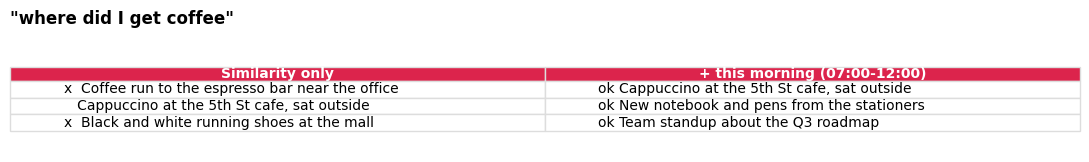

In [3]:
from helper import (
    search_memories, embed_query, time_window,
    all_of, two_column_table,
)

q = embed_query("where did I get coffee")
before = [h.payload["note"] for h in
         search_memories(shard, "text", q, limit=3)]

morning = all_of(time_window(at(7), at(12)))
after = [h.payload["note"] for h in
        search_memories(shard, "text", q, limit=3,
                        query_filter=morning)]

# Mark what the filter removed and what it kept, so the
# change reads at a glance.
before_m = [("x  " if b not in after else "   ") + b
           for b in before]
after_m = ["ok " + a for a in after]
two_column_table("Similarity only", before_m,
                 "+ this morning (07:00-12:00)", after_m,
                 title='"where did I get coffee"')

## 4. Money output: recall with a semantic query plus a payload filter

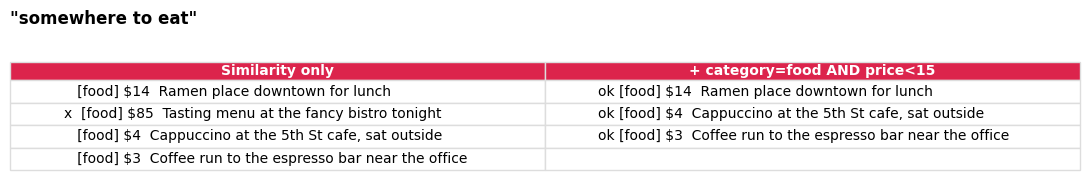

In [4]:
from helper import match, numeric

q2 = embed_query("somewhere to eat")
fmt = lambda h: (f"[{h.payload['category']}] "
                f"${h.payload['price']:.0f}  {h.payload['note']}")

before = [fmt(h) for h in
         search_memories(shard, "text", q2, limit=4)]
cheap_food = all_of(match("category", "food"), numeric("price", lt=15))
after = [fmt(h) for h in
        search_memories(shard, "text", q2, limit=4,
                        query_filter=cheap_food)]

before_m = [("x  " if b not in after else "   ") + b
           for b in before]
after_m = ["ok " + a for a in after]
two_column_table("Similarity only", before_m,
                 "+ category=food AND price<15", after_m,
                 title='"somewhere to eat"')

## 5. Money output: filtered vs. unfiltered latency

Store now holds 3007 memories
unfiltered 0.147 ms   filtered 0.023 ms


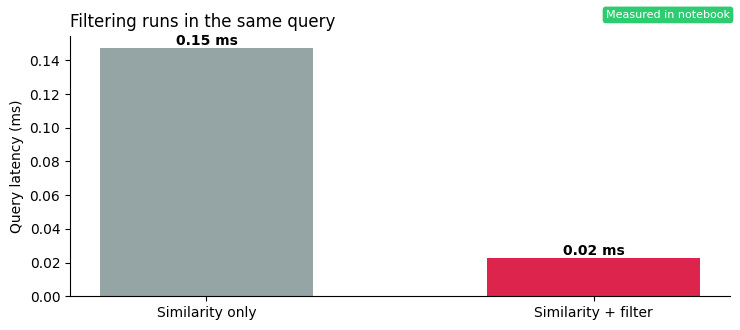

In [5]:
import numpy as np
from qdrant_edge import Point
from helper import filter_latency_chart, benchmark_query

# Grow to a realistic scale so the timing is credible
# (content is irrelevant to latency).
rng = np.random.default_rng(0)
cats = ["food", "work", "shopping", "travel"]
filler = rng.normal(size=(3000, NOMIC_DIM)).astype("float32")
shard.update(UpdateOperation.upsert_points([
    Point(id=1000 + i, vector={"text": filler[i].tolist()},
          payload={"category": cats[i % len(cats)],
                   "timestamp": at(rng.integers(-48, 24)),
                   "price": float(rng.integers(0, 100))})
    for i in range(len(filler))
]))
shard.optimize()
print("Store now holds", len(memories) + len(filler), "memories")

unfiltered = benchmark_query(shard, "text", q2, limit=4)
filtered = benchmark_query(
    shard, "text", q2, limit=4, query_filter=cheap_food,
)
print(f"unfiltered {unfiltered:.3f} ms   "
     f"filtered {filtered:.3f} ms")
filter_latency_chart(unfiltered, filtered)

## 6. The filter fields, for reference

| Field | Type | Example condition | Helper |
|---|---|---|---|
| `category` | keyword | `category = food` | `match("category", "food")` |
| `price` | float | `price < 15` | `numeric("price", lt=15)` |
| `timestamp` | float (epoch) | in `[start, end]` | `time_window(start, end)` |
| `location` | keyword / geo | `location = office` | `match("location", "office")` |

> Combine conditions with `all_of(...)` (AND) or `any_of(...)` (OR).

In [6]:
from helper import cleanup
cleanup(shard, "./mem_shard")
print("Cleaned up")

Cleaned up
